# Uniform Binning

-> Bins are of Same width.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

In [7]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Preprocessing
df = df[['Age', 'Survived']].dropna()

df.head()

,Age,Survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(df[['Age']], df['Survived'], test_size=0.2, random_state=42)

In [9]:
X_train

,Age
328,31.0
73,26.0
253,30.0
719,33.0
666,25.0
...,...
92,46.0
134,25.0
337,41.0
548,33.0


In [12]:
discretizer = KBinsDiscretizer(n_bins=5,encode = 'ordinal',strategy='uniform')

In [14]:
pd.DataFrame(discretizer.fit_transform(X_train), columns=discretizer.get_feature_names_out())

,Age
0,1.0
1,1.0
2,1.0
3,2.0
4,1.0
...,...
566,2.0
567,1.0
568,2.0
569,2.0


In [15]:
X_train_binned = pd.DataFrame(discretizer.fit_transform(X_train), columns=discretizer.get_feature_names_out())
X_test_binned = pd.DataFrame(discretizer.transform(X_test), columns=discretizer.get_feature_names_out())

In [17]:
X_train_binned.head()

,Age
0,1.0
1,1.0
2,1.0
3,2.0
4,1.0


In [21]:
discretizer.bin_edges_[0]

array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ])

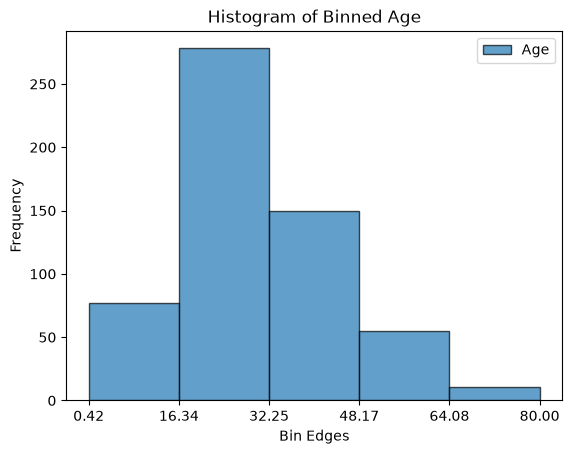

In [23]:
age_bin = discretizer.bin_edges_[0]

plt.hist(X_train['Age'] , bins=age_bin , alpha=0.7, edgecolor='black', label='Age')
plt.title('Histogram of Binned Age')
plt.xlabel('Bin Edges')
plt.ylabel('Frequency')
plt.xticks(age_bin)
plt.legend()
plt.show()